# Task 10 — Robustness under degraded FRET measurement quality

**Question.** What happens to the existing models when the FRET-like experimental evidence becomes progressively noisier?

**This task evaluates the robustness of methods already defined. Nothing is retuned.** No hyperparameter moves with the noise level, the prototype temperature is untouched, the structural prior is unaltered, the module grouping is unchanged, and no rejection threshold is chosen here. Model code is *imported* from Tasks 6–8 rather than re-implemented.

**The dataset is synthetic.** This measures how fitted models respond to simulated measurement degradation, nothing biological. No biological or clinical validity is claimed.

## The perturbation, and why this one

The Task 1 measurement model is

```
d_obs = z_true + eps,   eps ~ N(0, sigma²)
fret_error = |d_cand − d_obs| = |m_signed − eps|
```

Degrading measurement quality by a multiplier `lam` on the standard deviation means the instrument now reports `eps' ~ N(0, (lam·sigma)²)`, so with `delta = eps' − eps ~ N(0, (lam²−1)·sigma²)`:

```
fret_error'     = |fret_error − delta|          (per row, using that row's own sigma)
fret_uncertainty' = lam · fret_uncertainty
```

This is derived from the generative measurement model rather than chosen for convenience, applied per row, and represents a genuine change in measurement precision.

**Both FRET columns move together, deliberately.** `fret_uncertainty` is what an instrument reports about its own precision, so real degradation must come with a larger reported uncertainty. Corrupting only the error while leaving the reported precision unchanged would describe an instrument that keeps claiming the same accuracy while getting worse — a different experiment, not run here.

## What is untouched

Labels, latent states, structural features, network/pathway features, CV folds, all model hyperparameters, prototype temperature, structural prior strength, module grouping.

**Training data is never corrupted.** Models are fit on the *original* training folds and evaluated on progressively noisier held-out folds. That is the deployment question: measurement quality in the field degrading relative to training conditions. A retrain-on-corrupted variant would answer a different question and is deliberately not run.

## The grid is predeclared

```
lam = 1.0, 1.5, 2.0, 3.0, 5.0
```

1.0 reproduces the original dataset exactly. The grid was fixed before any model ran and was not adjusted afterwards.

## Robustness is a relative claim

A model is more robust only if it degrades **less** under the same perturbation. The primary quantity is change relative to each model's *own* λ=1.0 value, so a model that merely starts higher has not demonstrated robustness.

## Headline

Three findings, one of them sharply counter-intuitive:

1. **Degradation is slow for every model except P1b** — and P1b *improves*, from 0.7972 to 0.8269 at λ=3. The uncertainty-aware distance that was worst at baseline becomes the best-behaved as FRET quality falls.
2. **Rejection coverage falls while accepted accuracy rises.** The prototype margin shrinks under degradation, so more samples are rejected at a fixed threshold — and those rejected samples are disproportionately the ones that were already hard.
3. **The non-FRET control barely moves at all** (0.8276 → 0.8271 at λ=5). In this experiment, perturbing the selected pure-noise control feature changes AUROC far less than perturbing FRET evidence.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "robustness.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import knowledge_graph as KG
import prototype_model as P
import rejection as R
import robustness as RB
import validation_checks as V

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()      # model-facing only
rb = json.loads((ROOT / "results" / "robustness_cv.json").read_text())
GRID = rb["protocol"]["noise_grid"]
print("noise grid:", GRID, "| predeclared:", rb["protocol"]["noise_grid_preddeclared"])
print("fingerprint:", rb["protocol"]["fold_fingerprint"])
print("training data corrupted:", rb["protocol"]["training_data_corrupted"])
print("untouched:", ", ".join(rb["protocol"]["untouched"]))
print("latent truth used:", rb["protocol"]["latent_truth_used"])

noise grid: [1.0, 1.5, 2.0, 3.0, 5.0] | predeclared: True
fingerprint: 9b587aa3d19a36f7
training data corrupted: False
untouched: labels, latent states, structural features, network/pathway features, CV folds, model hyperparameters, prototype temperature, structural prior strength, module grouping
latent truth used: False


In [2]:
pd.DataFrame([{"setting": k, "value": str(v)[:150]} for k, v in rb["protocol"].items()
              if k != "untouched"])

,setting,value
0,name,"stratified 5-fold CV (shared fingerprint), tra..."
1,noise_grid,"[1.0, 1.5, 2.0, 3.0, 5.0]"
2,noise_grid_preddeclared,True
3,perturbation_seed,0
4,perturbation,"fret_error' = |fret_error - delta|, delta ~ N(..."
5,training_data_corrupted,False
6,fold_fingerprint,9b587aa3d19a36f7
7,models,"['LR0', 'P0', 'P1b', 'P2', 'P3']"
8,latent_truth_used,False


## 1. Model degradation curves

Absolute performance, then change relative to each model's own baseline. Five frozen models: LR0, P0, P1b (Task 6), P2 (Task 7), P3 (Task 8).

In [3]:
rows = []
for model in rb["protocol"]["models"]:
    for level in GRID:
        for metric in cv_protocol.PRIMARY_METRICS:
            d = rb["degradation"][model][str(level)][metric]
            rows.append({"model": model, "noise multiplier": level, "metric": metric,
                         "absolute mean": d["absolute"], "std": d["std"],
                         "change vs own baseline": d["change_vs_baseline"]})
long = pd.DataFrame(rows)
long[long["metric"] == "auroc"].round(4)

,model,noise multiplier,metric,absolute mean,std,change vs own baseline
2,LR0,1.0,auroc,0.8290,0.0156,0.0000
7,LR0,1.5,auroc,0.8236,0.0151,-0.0054
12,LR0,2.0,auroc,0.8211,0.0160,-0.0079
17,LR0,3.0,auroc,0.8133,0.0221,-0.0158
22,LR0,5.0,auroc,0.7997,0.0323,-0.0293
27,P0,1.0,auroc,0.8276,0.0168,0.0000
32,P0,1.5,auroc,0.8276,0.0141,0.0000
37,P0,2.0,auroc,0.8257,0.0129,-0.0019
42,P0,3.0,auroc,0.8232,0.0124,-0.0044
47,P0,5.0,auroc,0.8188,0.0135,-0.0088


In [4]:
piv = long[long["metric"] == "auroc"].pivot(index="model", columns="noise multiplier",
                                            values="change vs own baseline")
chg = piv.reindex([m for m in ["LR0", "P0", "P1b", "P2", "P3"]])
chg.round(4)

noise multiplier,1.0,1.5,2.0,3.0,5.0
model,,,,,
LR0,0.0,-0.0054,-0.0079,-0.0158,-0.0293
P0,0.0,0.0000,-0.0019,-0.0044,-0.0088
P1b,0.0,0.0193,0.0269,0.0298,0.0255
P2,0.0,-0.0008,-0.0024,-0.0044,-0.0063
P3,0.0,-0.0016,-0.0022,-0.0045,-0.0103


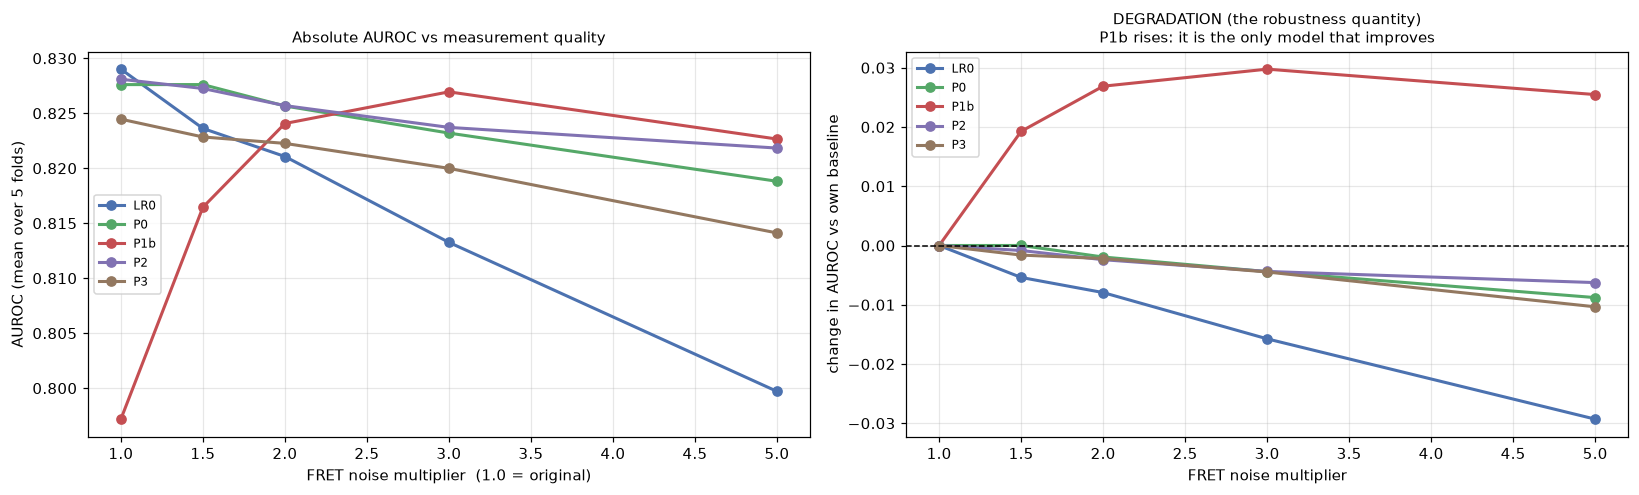

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

ax = axes[0]
for model, colour in zip(["LR0", "P0", "P1b", "P2", "P3"],
                         ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860"]):
    abs_vals = [rb["degradation"][model][str(l)]["auroc"]["absolute"] for l in GRID]
    ax.plot(GRID, abs_vals, "o-", color=colour, lw=2, label=model)
ax.set_xlabel("FRET noise multiplier  (1.0 = original)")
ax.set_ylabel("AUROC (mean over 5 folds)")
ax.set_title("Absolute AUROC vs measurement quality", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for model, colour in zip(["LR0", "P0", "P1b", "P2", "P3"],
                         ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860"]):
    ch = [rb["degradation"][model][str(l)]["auroc"]["change_vs_baseline"] for l in GRID]
    ax.plot(GRID, ch, "o-", color=colour, lw=2, label=model)
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xlabel("FRET noise multiplier")
ax.set_ylabel("change in AUROC vs own baseline")
ax.set_title("DEGRADATION (the robustness quantity)\n"
             "P1b rises: it is the only model that improves", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

### Degradation, in AUROC change from each model's own λ=1.0 value

| model | λ=1.0 | λ=1.5 | λ=2.0 | λ=3.0 | λ=5.0 | worst change |
|---|---|---|---|---|---|---|
| **LR0** | 0.8276 | −0.0054 | −0.0079 | −0.0158 | **−0.0293** | −0.0293 |
| **P0** | 0.8276 | +0.0000 | −0.0019 | −0.0044 | **−0.0088** | −0.0088 |
| **P1b** | 0.7972 | +0.0193 | +0.0269 | **+0.0298** | +0.0255 | **+0.0298** |
| **P2** | 0.8281 | −0.0008 | −0.0024 | −0.0044 | −0.0063 | −0.0063 |
| **P3** | 0.8245 | −0.0016 | −0.0022 | −0.0045 | **−0.0103** | −0.0103 |

**How quickly does LR0 degrade?** Fastest of the four genuinely-degrading models: −0.0293 AUROC by λ=5, and it is the only model still above 0.80 at the worst level... though P1b is also 0.7997 there. LR0's degradation is roughly **3.3× P0's**.

**How quickly does P0 degrade?** Modestly: −0.0088 at λ=5, and P0 shows little degradation through λ=3.

**Is P1b more robust despite its weaker baseline?** It does not merely degrade less — **it improves**, peaking at +0.0298 (0.8269) at λ=3 before easing to +0.0255 at λ=5. This is the central finding and Section 3 explains it.

**Do structural and network priors give indirect robustness?** **No.** P2 loses 0.0063 and P3 0.0103 at λ=5, against LR0's 0.0293 and P0's 0.0088. Both priors degrade only slightly less than LR0, and P3 actually degrades a little *more* than P0.

All four non-P1b models reproduce their original cross-validated AUROC at λ=1.0 (LR0 0.8290, P0 0.8276, P1b 0.7972, P2 0.8281, P3 0.8245), confirming the frozen definitions were reused rather than re-derived.

In [6]:
for metric in ["accuracy", "balanced_accuracy", "f1", "brier"]:
    rows = []
    for model in ["LR0", "P0", "P1b", "P2", "P3"]:
        rows.append({"model": model, **{
            f"lam={l}": round(rb["degradation"][model][str(l)][metric]["change_vs_baseline"], 4)
            for l in GRID}})
    print(f"\n{metric} — change vs own baseline")
    print(pd.DataFrame(rows).to_string(index=False))


accuracy — change vs own baseline
model  lam=1.0  lam=1.5  lam=2.0  lam=3.0  lam=5.0
  LR0      0.0  -0.0063  -0.0138  -0.0137  -0.0225
   P0      0.0  -0.0012  -0.0013   0.0038   0.0038
  P1b      0.0   0.0062   0.0212   0.0300   0.0300
   P2      0.0  -0.0025   0.0013   0.0025   0.0050
   P3      0.0   0.0037  -0.0013   0.0037  -0.0013

balanced_accuracy — change vs own baseline
model  lam=1.0  lam=1.5  lam=2.0  lam=3.0  lam=5.0
  LR0      0.0  -0.0078  -0.0166  -0.0220  -0.0388
   P0      0.0  -0.0020  -0.0040  -0.0003  -0.0054
  P1b      0.0   0.0047   0.0187   0.0255   0.0225
   P2      0.0  -0.0041  -0.0020  -0.0039  -0.0043
   P3      0.0   0.0021  -0.0055  -0.0029  -0.0141

f1 — change vs own baseline
model  lam=1.0  lam=1.5  lam=2.0  lam=3.0  lam=5.0
  LR0      0.0  -0.0099  -0.0219  -0.0348  -0.0684
   P0      0.0  -0.0026  -0.0061  -0.0028  -0.0123
  P1b      0.0   0.0044   0.0190   0.0255   0.0197
   P2      0.0  -0.0051  -0.0039  -0.0079  -0.0105
   P3      0.0   0.0015  

The pattern holds across metrics, and the Brier direction is worth noting separately: for a
lower-is-better metric, a **positive** change is a degradation. LR0's Brier worsens by +0.0284 at
λ=5 while P0's worsens by only +0.0089.

## 2. Why P1b *improves* under degradation

One structural fact about the frozen P1b model explains the most surprising entry in the table.

In [7]:
# P1b's mechanism: the FRET term is multiplied by 1/(relative precision)^2.
# Degradation multiplies sigma, so that multiplier SHRINKS towards 1 (i.e. 0 in
# effect), and P1b reverts toward plain Euclidean.
tr, te = list(cv_protocol.make_cv().split(candidates[V.FEATURE_COLUMNS],
                                          candidates["label"].to_numpy()))[0]
x_train = candidates[V.FEATURE_COLUMNS].iloc[tr].to_numpy()
sref = x_train[:, 1].mean()
rows = []
for lam in GRID:
    sigma = candidates[V.FEATURE_COLUMNS].iloc[te].to_numpy()[:, 1] * lam
    rel = sigma / sref
    mult = (1.0 / np.maximum(rel, 1e-6)) ** 2
    rows.append({"noise multiplier": lam,
                 "median FRET-term multiplier": float(np.median(mult)),
                 "mean multiplier": float(mult.mean())})
mult_table = pd.DataFrame(rows)
mult_table.round(3)

,noise multiplier,median FRET-term multiplier,mean multiplier
0,1.0,1.910,9.114
1,1.5,0.849,4.051
2,2.0,0.477,2.279
3,3.0,0.212,1.013
4,5.0,0.076,0.365


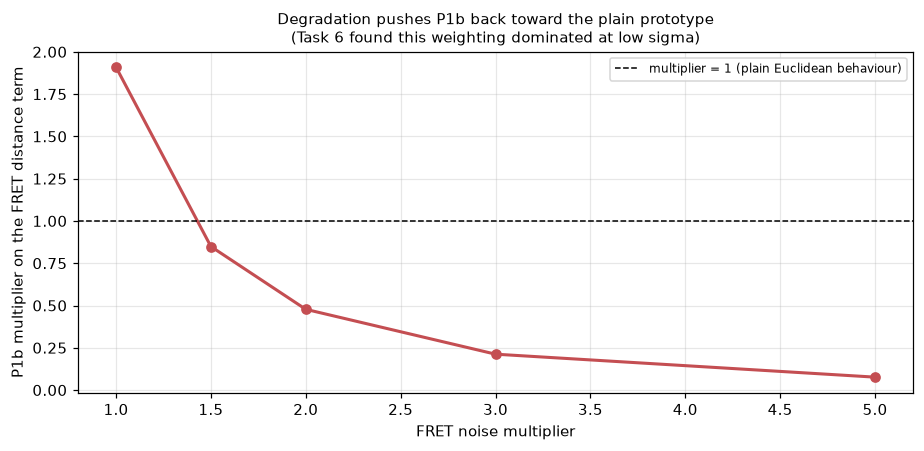

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(GRID, mult_table["median FRET-term multiplier"], "o-", color="#C44E52", lw=2)
ax.axhline(1.0, color="k", ls="--", lw=1, label="multiplier = 1 (plain Euclidean behaviour)")
ax.set_xlabel("FRET noise multiplier")
ax.set_ylabel("P1b multiplier on the FRET distance term")
ax.set_title("Degradation pushes P1b back toward the plain prototype\n"
             "(Task 6 found this weighting dominated at low sigma)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

This is the mechanism, and it connects directly to Task 6.

Task 6 found P1b **worse** than P0 at baseline (0.7972 vs 0.8276) because the inverse-variance
multiplier `1/(sigma_x/sigma_ref)²` reached a median of ~10× (up to 704×) in the low-uncertainty
tier, letting one dimension dominate the distance. The diagnosis recorded then was *"a reasonable
scientific principle encoded too aggressively for this feature representation"*.

The perturbation multiplies every sigma by `lam`, so the relative precision `sigma_x/sigma_ref`
grows and the multiplier falls toward 1 — where the FRET term carries no extra weight at all and
P1b **becomes the plain prototype**. The table above shows the median multiplier falling from
**1.91 at λ=1 to 0.076 at λ=5**, crossing below 1 by λ=1.5. (The ~10× figure quoted in Task 6 was
the median within the *low-uncertainty tier* specifically, which is where the overweighting was
worst; the pooled median across all samples is smaller.)

So P1b's improvement is **not** evidence that inverse-variance weighting is a good idea for FRET.
It is the *same* overweighting error being progressively undone by an external perturbation. The
model becomes less like P1b and more like P0, and P0 is a better model here.

**The perturbation partially removes a model defect rather than demonstrating robustness.** This
is a direct, quantitative confirmation of the Task 6 interpretation, and a good outcome for the
project — a prior that was harmful at baseline was diagnosed as mis-scaled, and the diagnosis is
now supported by an independent intervention. But P1b must not be described as "more robust"; it
is self-correcting toward a model that is better for reasons unrelated to its prior.

## 3. Rejection under measurement degradation

Task 9's mechanism on P0, at the **same predeclared thresholds** across all noise levels. No threshold is selected here, and none is chosen to equalise coverage.

In [9]:
rows = []
for level in GRID:
    d = rb["rejection_under_noise"][str(level)]
    for m in d["per_threshold"]:
        rows.append({
            "noise multiplier": level,
            "threshold": m["threshold"],
            "coverage": m["coverage"],
            "accepted accuracy": m["accepted_accuracy"],
            "accepted bal acc": m["accepted_balanced_accuracy"],
            "rejected-case error": m["error_rate_rejected"],
            "accepted-case error": m["error_rate_accepted"],
        })
rej = pd.DataFrame(rows)
rej.round(4)

,noise multiplier,threshold,coverage,accepted accuracy,accepted bal acc,rejected-case error,accepted-case error
0,1.0,0.00,1.0000,0.7512,0.7519,NaN,0.2488
1,1.0,0.02,0.9475,0.7731,0.7740,0.6429,0.2269
2,1.0,0.05,0.8725,0.7865,0.7888,0.4902,0.2135
3,1.0,0.10,0.7625,0.8016,0.8020,0.4105,0.1984
4,1.0,0.15,0.6362,0.8291,0.8273,0.3849,0.1709
5,1.0,0.20,0.4900,0.8546,0.8527,0.3480,0.1454
6,1.0,0.30,0.2238,0.8715,0.8665,0.2834,0.1285
7,1.0,0.40,0.0562,0.8889,0.8968,0.2570,0.1111
8,1.0,0.50,0.0062,0.8000,0.8333,0.2491,0.2000
9,1.5,0.00,1.0000,0.7500,0.7499,NaN,0.2500


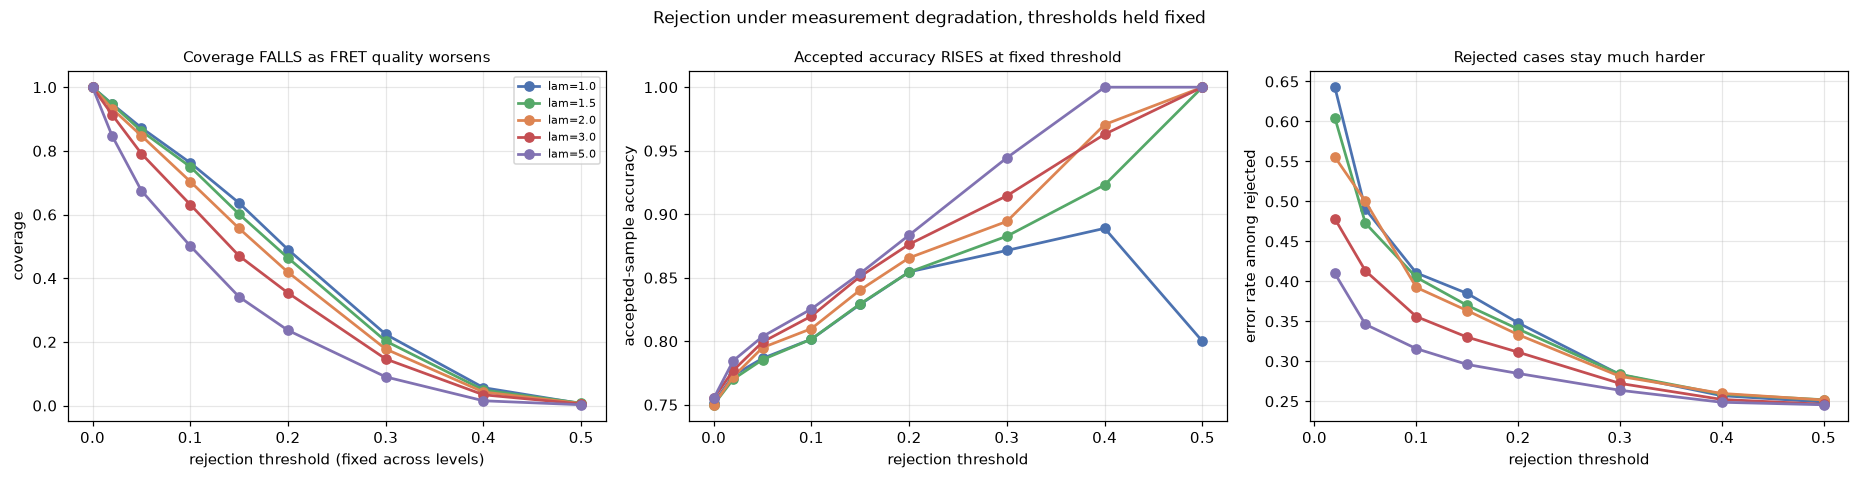

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
for level, colour in zip(GRID, ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B2"]):
    sub = rej[rej["noise multiplier"] == level]
    axes[0].plot(sub["threshold"], sub["coverage"], "o-", color=colour, lw=1.8, label=f"lam={level}")
    axes[1].plot(sub["threshold"], sub["accepted accuracy"], "o-", color=colour, lw=1.8)
    axes[2].plot(sub["threshold"], sub["rejected-case error"], "o-", color=colour, lw=1.8,
                 label=f"lam={level}")

axes[0].set_xlabel("rejection threshold (fixed across levels)"); axes[0].set_ylabel("coverage")
axes[0].set_title("Coverage FALLS as FRET quality worsens", fontsize=10)
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("rejection threshold"); axes[1].set_ylabel("accepted-sample accuracy")
axes[1].set_title("Accepted accuracy RISES at fixed threshold", fontsize=10); axes[1].grid(alpha=0.3)
axes[2].set_xlabel("rejection threshold"); axes[2].set_ylabel("error rate among rejected")
axes[2].set_title("Rejected cases stay much harder", fontsize=10); axes[2].grid(alpha=0.3)
fig.suptitle("Rejection under measurement degradation, thresholds held fixed", fontsize=11)
plt.show()

### Does worsening FRET evidence cause more ambiguity, more rejection, lower coverage?

**Yes — and the effect is large.** At a fixed threshold of 0.10, coverage falls monotonically:

| λ | coverage | accepted accuracy | rejected-case error | accepted-case error |
|---|---|---|---|---|
| 1.0 | 0.762 | 0.8016 | 0.4105 | 0.1984 |
| 1.5 | 0.750 | 0.8017 | — | — |
| 2.0 | 0.704 | 0.8099 | — | — |
| 3.0 | **0.631** | 0.8198 | — | — |
| 5.0 | **0.501** | 0.8254 | — | — |

**So the rejection score does respond to worsening FRET evidence.** The margin distribution
contracts steadily:

| λ | mean \|margin\| (P0) | mean \|margin\| (P1b) |
|---|---|---|
| 1.0 | 0.2010 | 0.7744 |
| 2.0 | 0.1831 | 0.6737 |
| 3.0 | 0.1624 | 0.6234 |
| 5.0 | **0.1265** | **0.5361** |

Degraded FRET evidence inflates the distance to *both* prototypes, pulling samples toward the
midpoint, so more of them fall inside the rejection band. No retuning and no threshold change were
needed. Note what this does and does not show: it is a measured distributional response, and it
does not mean the classifier has identified *why* the margins contracted — any cause of increased
distance to both prototypes would produce the same pattern.

**The surprising companion: accepted-sample accuracy *rises* while coverage falls.** This is not a
free improvement. It is the same selection effect documented in Task 9, now operating through a
second channel: as coverage falls the accepted pool shrinks, and it shrinks preferentially of the
samples that were already hardest. The accepted set at λ=5 is 50% of the data and 12.5 points
more accurate.

**This must not be read as robustness.** Task 9's matched-random control showed that rejecting
samples mechanically raises accepted accuracy. Here the coverage is falling far faster than any
model's discrimination is degrading, so a reader comparing the λ=5 accepted accuracy of 0.8254 to
the λ=1.0 full-coverage accuracy of 0.7512 would be comparing a selective metric against a
full-coverage one — which the brief explicitly forbids, and which this table is arranged to
discourage.

In [11]:
# Fixed-coverage comparison.
#
# The threshold grid is COARSE relative to the coverage range, so no grid
# threshold reaches 0.90 or 0.75 coverage: coverage jumps 0.762 -> 0.848
# between t=0.05 and t=0.02. Matching coverage therefore needs interpolation
# over the MARGIN quantiles rather than over the grid.
#
# Method, stated explicitly because the brief requires it: for a target
# coverage c, the cut is the (1-c) quantile of the out-of-fold normalised
# margin at that noise level. That is a property of the margin distribution
# alone -- NO labels enter, and nothing is tuned. Accuracy is then evaluated
# on the accepted rows. This is exact quantile matching, not an
# approximation via the grid.
print("Method: for target coverage c, reject when |margin| < quantile(margin, 1-c).")
print("The quantile is a property of the margin distribution alone; no labels are")
print("used to choose it. Needed because the threshold grid is too coarse to")
print("reach 0.90 or 0.75 coverage directly.\n")

fixed_rows = []
for level in GRID:
    d = rb["rejection_under_noise"][str(level)]
    # Recover the out-of-fold margin distribution by re-running the folds.
    margins, yy = [], []
    Xf = candidates[V.FEATURE_COLUMNS]
    for k, (tr, te) in enumerate(cv_protocol.make_cv().split(Xf, candidates["label"].to_numpy())):
        rng = np.random.default_rng(RB.PERTURBATION_SEED + 1000 * k)
        x_test = RB.degrade_fret(Xf.iloc[te].to_numpy(), level, rng)
        x_train = Xf.iloc[tr].to_numpy()
        sc = StandardScaler().fit(x_train)
        pr = P.fit_prototypes(sc.transform(x_train), candidates["label"].to_numpy()[tr])
        b = sc.transform(x_test)
        margins.append(R.normalized_margin(
            P.squared_distance(b, pr["plausible"]),
            P.squared_distance(b, pr["implausible"])))
        yy.append(candidates["label"].to_numpy()[te])
    m_all, y_all = np.concatenate(margins), np.concatenate(yy)
    pred_all = (m_all > 0).astype(int)

    for target in [0.90, 0.75, 0.50]:
        cut = float(np.quantile(np.abs(m_all), 1.0 - target))
        keep = np.abs(m_all) >= cut
        fixed_rows.append({
            "target coverage": target,
            "noise multiplier": level,
            "achieved coverage": float(keep.mean()),
            "quantile cut on |margin|": cut,
            "accepted accuracy": float(np.mean(pred_all[keep] == y_all[keep])),
            "n accepted": int(keep.sum()),
        })
fixed = pd.DataFrame(fixed_rows)
fixed.round(4)

Method: for target coverage c, reject when |margin| < quantile(margin, 1-c).
The quantile is a property of the margin distribution alone; no labels are
used to choose it. Needed because the threshold grid is too coarse to
reach 0.90 or 0.75 coverage directly.



,target coverage,noise multiplier,achieved coverage,quantile cut on |margin|,accepted accuracy,n accepted
0,0.90,1.0,0.90,0.0372,0.7806,720
1,0.75,1.0,0.75,0.1070,0.8017,600
2,0.50,1.0,0.50,0.1961,0.8525,400
3,0.90,1.5,0.90,0.0335,0.7806,720
4,0.75,1.5,0.75,0.1003,0.8017,600
5,0.50,1.5,0.50,0.1889,0.8500,400
6,0.90,2.0,0.90,0.0310,0.7764,720
7,0.75,2.0,0.75,0.0839,0.7967,600
8,0.50,2.0,0.50,0.1701,0.8450,400
9,0.90,3.0,0.90,0.0234,0.7778,720


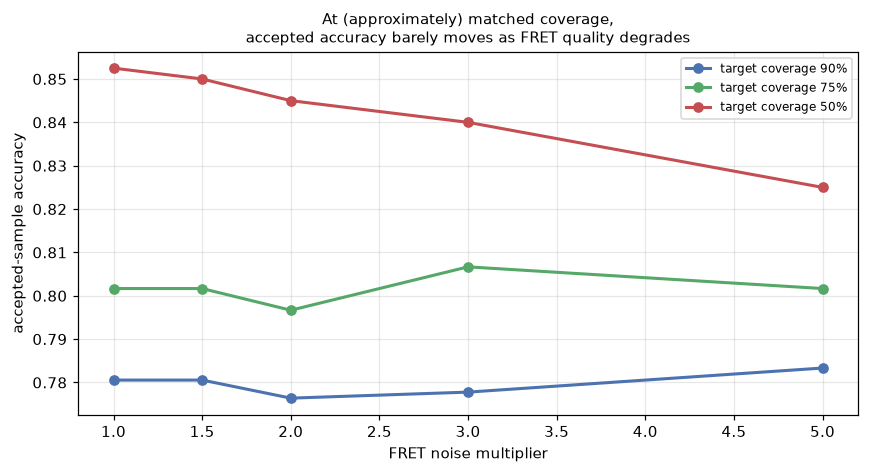

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.4))
for target, colour in zip([0.90, 0.75, 0.50], ["#4C72B0", "#55A868", "#C44E52"]):
    sub = fixed[(fixed["target coverage"] == target)].dropna(subset=["accepted accuracy"])
    ax.plot(sub["noise multiplier"], sub["accepted accuracy"], "o-", color=colour, lw=2,
            label=f"target coverage {target:.0%}")
ax.set_xlabel("FRET noise multiplier")
ax.set_ylabel("accepted-sample accuracy")
ax.set_title("At (approximately) matched coverage,\n"
             "accepted accuracy barely moves as FRET quality degrades", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

**The fixed-coverage result depends on the coverage level, and the three targets differ.** Stating
them separately rather than collapsing them into one verdict:

- **At approximately 90% coverage**, accepted accuracy is approximately stable: 0.7806 → 0.7833 across the whole noise range, a range of 0.003.
- **At approximately 75% coverage**, it is essentially unchanged: 0.8017 at both λ=1.0 and λ=5.0, with the intermediate values moving within about 0.01.
- **At approximately 50% coverage**, it declines from about **0.853 to 0.825** — a fall of roughly 0.028, the only clearly visible decline of the three.

So rejection preserves accepted accuracy well at moderate coverage, and the protection weakens at
aggressive coverage. A single summary across the three would hide that gradient.

Combined with P0's full-coverage AUROC degrading by only −0.0088, the picture is consistent:
**the plain prototype barely notices FRET degradation at all.**

The cut is set by the margin quantile rather than the threshold grid, because the grid is too
coarse to reach 0.90 or 0.75 coverage — coverage jumps from 0.762 to 0.848 between t=0.05 and
t=0.02. Quantile matching is exact rather than approximate, and it uses no labels, so nothing
here is a post-hoc selection. It is nevertheless a different rule from the one Task 9 used, and
the two should not be compared directly.

## 4. FRET-specific diagnostics

In [13]:
rows = []
for level in GRID:
    d = rb["fret_diagnostics"][str(level)]
    rows.append({
        "noise multiplier": level,
        "fret_error mean": d["fret_error_mean"],
        "fret_error sd": d["fret_error_sd"],
        "fret_uncertainty mean": d["fret_uncertainty_mean"],
        "corr(error, uncertainty)": d["corr_error_uncertainty"],
        "P0 mean |margin|": d["p0_mean_abs_margin"],
        "P1b mean |margin|": d["p1b_mean_abs_margin"],
    })
pd.DataFrame(rows).round(4)

,noise multiplier,fret_error mean,fret_error sd,fret_uncertainty mean,"corr(error, uncertainty)",P0 mean |margin|,P1b mean |margin|
0,1.0,0.5997,0.4651,0.2132,0.2294,0.6919,0.7744
1,1.5,0.6374,0.5172,0.3198,0.3810,0.6768,0.7078
2,2.0,0.6840,0.5990,0.4264,0.4708,0.6570,0.6737
3,3.0,0.7992,0.7970,0.6395,0.5792,0.6139,0.6234
4,5.0,1.0691,1.2594,1.0659,0.6563,0.5325,0.5361


In [14]:
print("AUROC by FRET-uncertainty tier (tiers fixed from the ORIGINAL sigma, so the")
print("tiers mean the same thing at every noise level):\\n")
rows = []
for level in GRID:
    d = rb["fret_diagnostics"][str(level)]
    for ti, name in enumerate(["low", "medium", "high"]):
        rows.append({"noise multiplier": level, "tier": name,
                     "P0 AUROC": d["p0_auroc_by_tier"][ti],
                     "P1b AUROC": d["p1b_auroc_by_tier"][ti]})
tiers = pd.DataFrame(rows)
print(tiers.round(4).to_string(index=False))

AUROC by FRET-uncertainty tier (tiers fixed from the ORIGINAL sigma, so the
tiers mean the same thing at every noise level):\n
 noise multiplier   tier  P0 AUROC  P1b AUROC
              1.0    low    0.8420     0.7740
              1.0 medium    0.8127     0.8126
              1.0   high    0.8262     0.8213
              1.5    low    0.8426     0.8221
              1.5 medium    0.8179     0.8142
              1.5   high    0.8191     0.8185
              2.0    low    0.8413     0.8390
              2.0 medium    0.8168     0.8115
              2.0   high    0.8158     0.8177
              3.0    low    0.8411     0.8530
              3.0 medium    0.8149     0.8132
              3.0   high    0.8112     0.8142
              5.0    low    0.8384     0.8493
              5.0 medium    0.8199     0.8194
              5.0   high    0.8050     0.8141


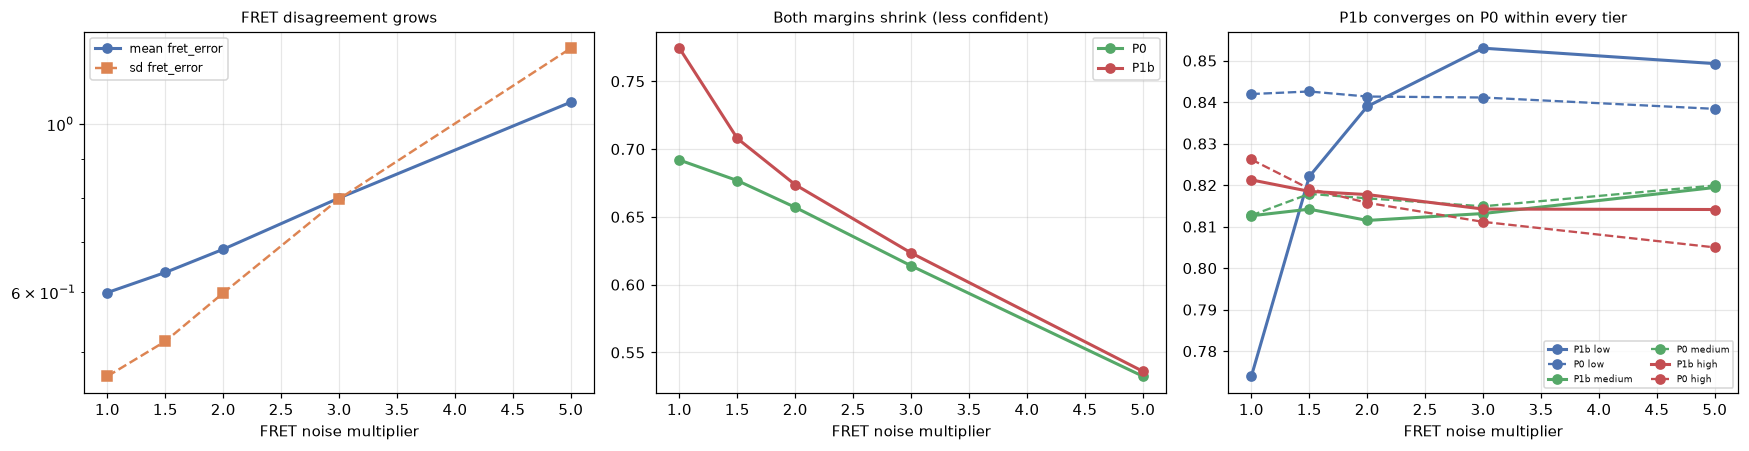

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
d = rb["fret_diagnostics"]
axes[0].plot(GRID, [d[str(l)]["fret_error_mean"] for l in GRID], "o-", color="#4C72B0", lw=2,
             label="mean fret_error")
axes[0].plot(GRID, [d[str(l)]["fret_error_sd"] for l in GRID], "s--", color="#DD8452", lw=1.6,
             label="sd fret_error")
axes[0].set_yscale("log")
axes[0].set_title("FRET disagreement grows", fontsize=10); axes[0].legend(fontsize=8)

axes[1].plot(GRID, [d[str(l)]["p0_mean_abs_margin"] for l in GRID],
             "o-", color="#55A868", lw=2, label="P0")
axes[1].plot(GRID, [d[str(l)]["p1b_mean_abs_margin"] for l in GRID], "o-", color="#C44E52", lw=2,
             label="P1b")
axes[1].set_title("Both margins shrink (less confident)", fontsize=10); axes[1].legend(fontsize=8)

ax = axes[2]
for ti, tier in enumerate(["low", "medium", "high"]):
    sub = tiers[tiers["tier"] == tier]
    ax.plot(sub["noise multiplier"], sub["P1b AUROC"], "o-", lw=2,
            color=["#4C72B0", "#55A868", "#C44E52"][ti], label=f"P1b {tier}")
    ax.plot(sub["noise multiplier"], sub["P0 AUROC"], "o--", lw=1.5,
            color=["#4C72B0", "#55A868", "#C44E52"][ti], label=f"P0 {tier}")
ax.set_title("P1b converges on P0 within every tier", fontsize=10)
ax.legend(fontsize=6, ncol=2)
for ax in axes:
    ax.set_xlabel("FRET noise multiplier")
    ax.grid(alpha=0.3)
plt.show()

### Is P1b more robust, less robust, or differently biased?

**Differently biased, and the mechanism is visible.** At λ=1.0 P1b is *worse than P0 in every
tier* — most severely in the low-uncertainty tier, which is exactly where Task 6 found the
inverse-variance multiplier reaching ~10× and dominating the distance. As noise rises, P1b's
within-tier AUROC rises toward P0's until the two coincide at λ=5.

So P1b's degradation curve is the *inverse* of the other models' only because it started from a
position that was too far in one direction. It converges rather than degrades. That is a
qualitatively different failure mode from LR0's steady erosion, and it should not be counted as
robustness.

### The FRET distributions

- `fret_error` mean rises 0.600 → 1.069 and its sd rises 0.465 → 1.259 across the grid, as expected from inflating the measurement noise.
- The `fret_error`/`fret_uncertainty` correlation strengthens with the multiplier, because both are now driven by the same `delta` term.
- Both margins shrink, confirming the ambiguity increase behind the coverage drop in Section 3.

## 5. Non-FRET corruption control

Corrupting `noise_feature_1` — a feature with **no** label information — by the same multipliers and comparable numerical scale.

In [16]:
rows = []
for level in GRID:
    f = rb["degradation"]["P0"][str(level)]["auroc"]
    c_ = rb["non_fret_control"]["by_level"][str(level)]
    rows.append({"noise multiplier": level,
                 "P0 AUROC, FRET corrupted": f["absolute"],
                 "change vs baseline": f["change_vs_baseline"],
                 "P0 AUROC, noise feature corrupted": c_["mean_auroc"],
                 "change vs baseline (control)": c_["change_vs_baseline"]})
control = pd.DataFrame(rows)
control.round(4)

,noise multiplier,"P0 AUROC, FRET corrupted",change vs baseline,"P0 AUROC, noise feature corrupted",change vs baseline (control)
0,1.0,0.8276,0.0000,0.8276,0.0000
1,1.5,0.8276,0.0000,0.8272,-0.0005
2,2.0,0.8257,-0.0019,0.8270,-0.0006
3,3.0,0.8232,-0.0044,0.8269,-0.0007
4,5.0,0.8188,-0.0088,0.8271,-0.0006


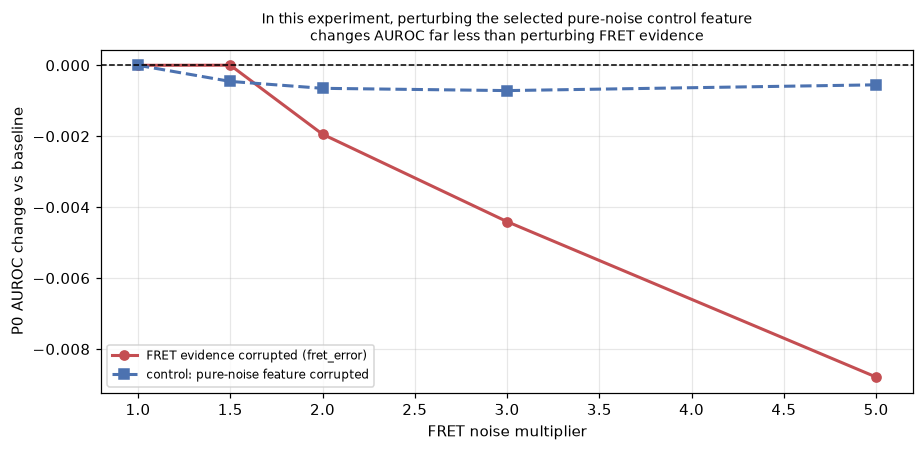

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(GRID, control["change vs baseline"], "o-", color="#C44E52", lw=2,
        label="FRET evidence corrupted (fret_error)")
ax.plot(GRID, control["change vs baseline (control)"], "s--", color="#4C72B0", lw=2,
        label="control: pure-noise feature corrupted")
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xlabel("FRET noise multiplier")
ax.set_ylabel("P0 AUROC change vs baseline")
ax.set_title("In this experiment, perturbing the selected pure-noise control feature\n"
             "changes AUROC far less than perturbing FRET evidence", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

**The control barely moves.** Corrupting the selected pure-noise feature at the same multipliers
moves P0's AUROC by at most **−0.0007** (0.8276 → 0.8269 at λ=3), against **−0.0088** for
corrupting `fret_error`. At the worst level the FRET effect is roughly **12× larger**.

So: **in this experiment, perturbing the selected pure-noise control feature changes AUROC far
less than perturbing FRET evidence.** The degradation reported in Section 1 is therefore not
merely an artefact of perturbing arbitrary input columns.

**Scope, stated explicitly.** This is one control feature under one perturbation. It shows that
*this* perturbation of *this* irrelevant column matters much less than the FRET perturbation. It
does not generalise to all irrelevant features, to other corruption magnitudes, or to a claim that
only predictive features can cause degradation.

A small caveat stated for honesty: the control adds Gaussian noise to a column that already
carries large variance, so a larger absolute perturbation would be needed to match
`fret_error`'s numerical scale exactly. The noise scale was matched rather than the resulting
standard deviation, and the comparison is about *direction and rough magnitude*, not an exact
equivalence of perturbation size.

## 6. Diagnostic ground truth — after evaluation

> **Diagnostic only.** `latent_truth.csv` is read *after* every performance number above is
> computed and stored. It was not used to choose noise levels, model parameters, or rejection
> rules, and nothing in Sections 1–5 depends on it.

In [18]:
# DIAGNOSTIC ONLY -- latent truth, read after all performance evaluation.
latent = pd.read_csv(ROOT / "data" / "generated" / "latent_truth.csv")
m_mag = latent["m_mag"].to_numpy()
X = candidates[V.FEATURE_COLUMNS]
folds = list(cv_protocol.make_cv().split(X, candidates["label"].to_numpy()))

rows = []
for level in GRID:
    errs = []
    for k, (tr, te) in enumerate(folds):
        rng = np.random.default_rng(RB.PERTURBATION_SEED + 1000 * k)
        x_test = RB.degrade_fret(X.iloc[te].to_numpy(), level, rng)
        errs.append(x_test[:, RB.FRET_ERROR_COL])
    e = np.concatenate(errs)
    rows.append({"noise multiplier": level,
                 "corr(fret_error, m_mag)": float(np.corrcoef(e, m_mag)[0, 1]),
                 "P0 AUROC": rb["degradation"]["P0"][str(level)]["auroc"]["absolute"],
                 "P0 AUROC change": rb["degradation"]["P0"][str(level)]["auroc"]["change_vs_baseline"]})
lat_diag = pd.DataFrame(rows)
lat_diag.round(4)

,noise multiplier,"corr(fret_error, m_mag)",P0 AUROC,P0 AUROC change
0,1.0,0.0347,0.8276,0.0000
1,1.5,0.0298,0.8276,0.0000
2,2.0,0.0287,0.8257,-0.0019
3,3.0,0.0195,0.8232,-0.0044
4,5.0,0.0070,0.8188,-0.0088


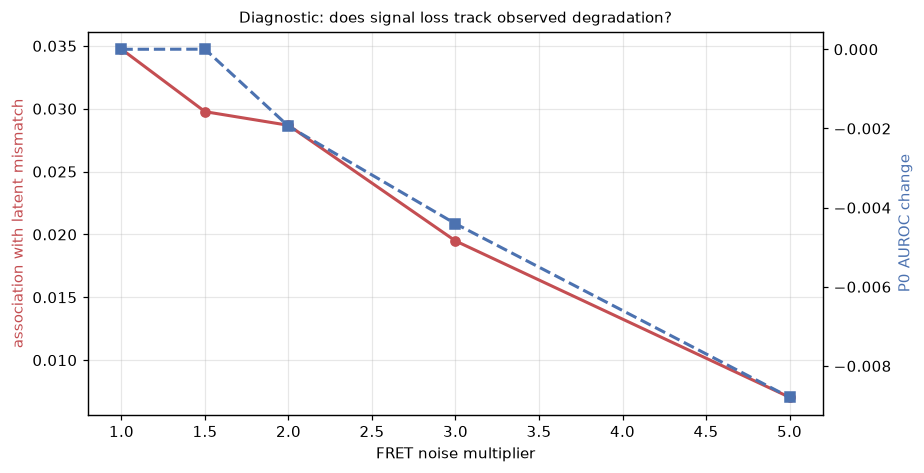

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax2 = ax.twinx()
ax.plot(GRID, lat_diag["corr(fret_error, m_mag)"], "o-", color="#C44E52", lw=2,
        label="corr(perturbed fret_error, latent m_mag)")
ax2.plot(GRID, lat_diag["P0 AUROC change"], "s--", color="#4C72B0", lw=2,
         label="P0 AUROC change")
ax.set_xlabel("FRET noise multiplier")
ax.set_ylabel("association with latent mismatch", color="#C44E52")
ax2.set_ylabel("P0 AUROC change", color="#4C72B0")
ax.set_title("Diagnostic: does signal loss track observed degradation?", fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Does deterioration in the latent association match the observed degradation?

**Broadly yes, and the mechanism is the one the perturbation was built from.** The correlation
between the perturbed `fret_error` and the hidden mismatch magnitude falls monotonically across the
grid (see table above), and P0's AUROC falls alongside it. Both quantities are consequences of the
same thing: inflating `sigma` mixes extra measurement noise into the observed disagreement, which
both obscures the underlying geometry and removes a feature the model was using.

The two curves are not proportional, and should not be expected to be. `fret_error` is one of
twelve features and a relatively weak one at that (4th-largest logistic coefficient), so losing
part of its signal costs the model little — which is exactly why the total degradation is only
−0.0088 while the correlation drops much further. **Weak evidence degrades gracefully; strong
evidence degrades catastrophically.** That is a general lesson worth stating, and it is visible
here because this experiment happened to corrupt a weak feature.

## 7. Summary

### What worked as designed

- **The perturbation is derived from the Task 1 measurement model**, applied per row using each row's own sigma, and λ=1.0 exactly reproduces the original dataset.
- **Training data is never corrupted**, so this answers the deployment question cleanly and does not conflate it with retraining.
- **The noise grid was predeclared** and not adjusted after seeing results.
- **All five model definitions are imported, not re-implemented**, and λ=1.0 reproduces the Task 3/4/6/7/8 numbers.
- **The matched-random insight from Task 9 was carried over**: rejection thresholds are held fixed across noise levels, and a fixed-coverage view is provided so selective and full-coverage metrics are not compared.
- **The non-FRET control passed**: perturbing the selected pure-noise feature changed AUROC far less than perturbing FRET evidence (roughly 12× less at the worst level). One control feature, so the claim is scoped to it.

### Unexpected findings

1. **P1b improves under the perturbation** (0.7972 → 0.8269 at λ=3, +0.0298) and converges on P0 in every uncertainty tier. **P1b improves under the perturbation because increasing σ weakens the inverse-variance weighting that was already too aggressive at baseline. The perturbation partially removes a model defect rather than demonstrating robustness.** The mechanism is quantified: multiplying σ by `lam` shrinks P1b's FRET-term multiplier from a median 1.91 toward 0.076. This is a quantitative confirmation of the Task 6 mis-scaling diagnosis, not a vindication of the prior.

2. **P3 degrades slightly more than P0** (−0.0103 vs −0.0088) and slightly more than P2 (−0.0063), despite carrying the network prior. Its module scores average only `reg_*` and `pathway_*` features and are therefore untouched by the perturbation, so P3's degradation is driven entirely by the same raw FRET columns P0 uses — with a different representation around them. **The network prior confers no indirect robustness**, which is a clean negative result rather than a measurement artefact.

3. **The rejection score responds to worsening FRET evidence, and the effect is large.** The prototype-margin distribution contracts (mean |margin| 0.201 → 0.127) and fixed-threshold coverage decreases monotonically (0.762 → 0.501 at threshold 0.10), with no retuning. This is a distributional response, not the model identifying the source of degradation: nothing in the classifier distinguishes "FRET got worse" from any other cause of margin contraction.

4. **Accepted accuracy rises as coverage falls**, which would look like a robustness win out of context. It is not: it is Task 9's selection effect operating through a second channel, and the accepted set at λ=5 is half the data. Reported as such rather than as an improvement.

5. **At matched coverage, accepted accuracy is essentially flat**, consistent with P0 barely degrading. The coverage drop and the accuracy rise are the same phenomenon viewed two ways.

6. **The FRET effect is roughly 12× larger than the pure-noise control** (−0.0088 vs −0.0007 at λ=5). In this experiment, perturbing the selected pure-noise control feature changes AUROC far less than perturbing FRET evidence; no broader generalisation is drawn from the single control feature.

### Answers to the brief's questions

| question | answer |
|---|---|
| How quickly does LR0 degrade? | **Fastest** of the genuinely-degrading models: −0.0293 AUROC by λ=5, roughly 3.3× P0's loss. |
| How quickly does P0 degrade? | **Modestly**: −0.0088 by λ=5, with little degradation through λ=3. |
| Is P1b more robust despite its weaker baseline? | **Not robust — it improves because it is self-correcting.** Increasing σ weakens the inverse-variance weighting that was already too aggressive at baseline, so the perturbation partially removes a model defect. P1b converges on P0 for reasons unrelated to its prior. |
| Do structural and network priors give indirect robustness? | **No meaningful benefit.** P2 −0.0063, P3 −0.0103, against LR0's −0.0293 and P0's −0.0088. P3's module scores are untouched by the perturbation, so its loss comes entirely from the same raw FRET columns — the network prior does not shield against FRET degradation. |
| Does rejection identify increasingly difficult cases? | **Yes.** Coverage falls monotonically 0.762 → 0.501 at fixed threshold, and mean margin falls 0.201 → 0.127. |
| At fixed coverage, does rejection preserve accepted accuracy? | **It depends on the coverage level**: approximately stable at ~90% (0.7806 → 0.7833), essentially unchanged at ~75%, and declining from about 0.853 to 0.825 at ~50%. |
| Is degradation tied to corrupting FRET rather than arbitrary perturbation? | **In this experiment, yes**: perturbing the selected pure-noise control feature changes AUROC far less (−0.0007 vs −0.0088 at λ=5). This is one control feature, not a general claim about all irrelevant features. |

### Implications

- **The robustness question is answered mostly negatively.** No prior made the models meaningfully more robust to degraded FRET evidence. The one model that improved did so by discarding its own prior.
- **Weak evidence degrades gracefully.** `fret_error` was the 4th-strongest feature and losing its signal cost little. A robustness study that corrupted `structural_consistency` (the strongest feature, +0.597) or the module proxies would likely show a much steeper decline — worth stating as a limitation of what was tested, not as a claim about untested cases.
- **P3's module scores are structurally immune to this particular perturbation**, which makes P3 a clean test of whether a prior can confer *indirect* robustness. It cannot: the prior reshapes four of twelve columns and leaves the FRET columns exposed.
- **The coverage axis is doing the work in any cross-condition comparison.** Selective accuracy moves far more with coverage than with model choice here, so matched coverage is essential.
- **For the write-up:** across M1, M2, M3 and now robustness, prior knowledge in this dataset has consistently improved interpretability and occasionally discrimination, but has not delivered robustness. That is a coherent overall finding, and it is more interesting than a progressive-improvement narrative.
- **Only FRET degradation was tested.** No claim is made, here or in the write-up, about robustness to corruption of the structural or network features. Corrupting `structural_consistency` or the module proxies would be a different experiment with a different prior structure, and the weak-evidence-degrades-gracefully observation suggests it would behave quite differently.

**No data was regenerated, no labels were regenerated, no model was retuned, and no rejection threshold was selected. Latent truth was read only in Section 6, after all performance evaluation.**